## Introduction to Probability and Statistics
## Assignment

In this assignment, we will use the dataset of diabetes patients taken [from here](https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html).

In [ ]:
!wget https://raw.githubusercontent.com/XW-ABAP/Data-Science-For-Beginners/main/data/diabetes.tsv -P sample_data/

--2026-10-08 08:06:50--  https://raw.githubusercontent.com/XW-ABAP/Data-Science-For-Beginners/main/data/diabetes.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18496 (18K) [text/plain]
Saving to: ‘sample_data/diabetes.tsv.1’

diabetes.tsv.1      100%[===================>]  18.06K  --.-KB/s    in 0.004s  

2026-10-08 08:06:50 (4.06 MB/s) - ‘sample_data/diabetes.tsv.1’ saved [18496/18496]



In [ ]:
import os
import requests

# 1. 定义根目录下的文件列表
root_files = [
    "SOCR_MLB.tsv",
    "UID_ISO_FIPS_LookUp_Table.csv",
    "birds.csv",
    "diabetes.tsv",
    "emails.csv",
    "form.csv",
    "honey.csv",
    "mushrooms.csv",
    "taxi.csv",
]

# 2. 定义 COVID 文件夹下的文件列表
covid_files = [
    "time_series_covid19_confirmed_global.csv",
    "time_series_covid19_deaths_global.csv",
    "time_series_covid19_recovered_global.csv",
]

# 确保目标基础目录存在
base_dir = "sample_data"
covid_target_dir = os.path.join(base_dir, "COVID")
os.makedirs(covid_target_dir, exist_ok=True)

# 基础 URL
github_base = (
    "https://raw.githubusercontent.com/XW-ABAP/Data-Science-For-Beginners/main/data/"
)

# 下载根目录文件到 sample_data/
print("--- 开始下载根目录文件 ---")
for file in root_files:
  url = github_base + file
  response = requests.get(url)
  if response.status_code == 200:
    file_path = os.path.join(base_dir, file)
    with open(file_path, "wb") as f:
      f.write(response.content)
    print(f"成功: {file}")
  else:
    print(f"失败 ({response.status_code}): {file}")

# 下载 COVID 文件夹文件到 sample_data/COVID/
print("\n--- 开始下载 COVID 文件夹文件 ---")
for file in covid_files:
  url = github_base + "COVID/" + file
  response = requests.get(url)
  if response.status_code == 200:
    file_path = os.path.join(covid_target_dir, file)
    with open(file_path, "wb") as f:
      f.write(response.content)
    print(f"成功: COVID/{file}")
  else:
    print(f"失败 ({response.status_code}): COVID/{file}")

print("\n所有文件同步完成！")

--- 开始下载根目录文件 ---
成功: SOCR_MLB.tsv
成功: UID_ISO_FIPS_LookUp_Table.csv
成功: birds.csv
成功: diabetes.tsv
成功: emails.csv
成功: form.csv
成功: honey.csv
成功: mushrooms.csv
成功: taxi.csv

--- 开始下载 COVID 文件夹文件 ---
成功: COVID/time_series_covid19_confirmed_global.csv
成功: COVID/time_series_covid19_deaths_global.csv
成功: COVID/time_series_covid19_recovered_global.csv

所有文件同步完成！


In [ ]:
import os

# 1. 打印当前的工作目录路径
print("当前工作目录:", os.getcwd())

# 2. 列出该目录下的所有文件和文件夹
print("目录下的文件:", os.listdir('.'))

当前工作目录: /content
目录下的文件: ['.config', 'drive', 'sample_data']


In [ ]:
import os

# 1. 打印当前的工作目录路径
print("当前工作目录:", os.getcwd())

# 2. 列出 sample_data 目录下的所有文件和文件夹
print("sample_data 目录下的文件:", os.listdir('sample_data'))

当前工作目录: /content
sample_data 目录下的文件: ['README.md', 'anscombe.json', 'diabetes.tsv.1', 'SOCR_MLB.tsv', 'mushrooms.csv', 'diabetes.tsv', 'birds.csv', 'form.csv', 'taxi.csv', 'honey.csv', 'UID_ISO_FIPS_LookUp_Table.csv', 'emails.csv', 'COVID', 'california_housing_train.csv', 'mnist_test.csv', 'california_housing_test.csv', 'mnist_train_small.csv']


In [ ]:
import pandas as pd
import numpy as np

# 从 sample_data 目录读取 diabetes.tsv 文件
df = pd.read_csv("sample_data/diabetes.tsv", sep='\t')
df.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



In this dataset, columns as the following:
* Age and sex are self-explanatory
* BMI is body mass index
* BP is average blood pressure
* S1 through S6 are different blood measurements
* Y is the qualitative measure of disease progression over one year

Let's study this dataset using methods of probability and statistics.

### Task 1: Compute mean values and variance for all values

In [ ]:
import pandas as pd
import numpy as np

# 从 sample_data 目录读取 diabetes.tsv 文件[cite: 1]
df = pd.read_csv("sample_data/diabetes.tsv", sep='\t')

# 1. 计算所有数值列的均值 (Mean)
mean_values = df.mean()
print("=== 各列均值 (Mean) ===")
print(mean_values)

print("\n" + "="*30 + "\n")

# 2. 计算所有数值列的方差 (Variance)
# 注：pandas 的 var() 默认计算的是样本方差（自由度 ddof=1）
var_values = df.var()
print("=== 各列方差 (Variance) ===")
print(var_values)

# 提示：如果你想一步到位查看包括均值、标准差、最大最小值等综合统计量，也可以直接使用：
# print(df.describe())

=== 各列均值 (Mean) ===
AGE     48.518100
SEX      1.468326
BMI     26.375792
BP      94.647014
S1     189.140271
S2     115.439140
S3      49.788462
S4       4.070249
S5       4.641411
S6      91.260181
Y      152.133484
dtype: float64


=== 各列方差 (Variance) ===
AGE     171.846610
SEX       0.249561
BMI      19.519798
BP      191.304401
S1     1197.717241
S2      924.955494
S3      167.293585
S4        1.665261
S5        0.272892
S6      132.165712
Y      5943.331348
dtype: float64


In [27]:
df.describe()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


### Task 2: Plot boxplots for BMI, BP and Y depending on gender

/tmp/ipykernel_1435/4194567894.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SEX', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_1435/4194567894.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SEX', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_1435/4194567894.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SEX', y=col, data=df, ax=axes[i], palette='Set2')


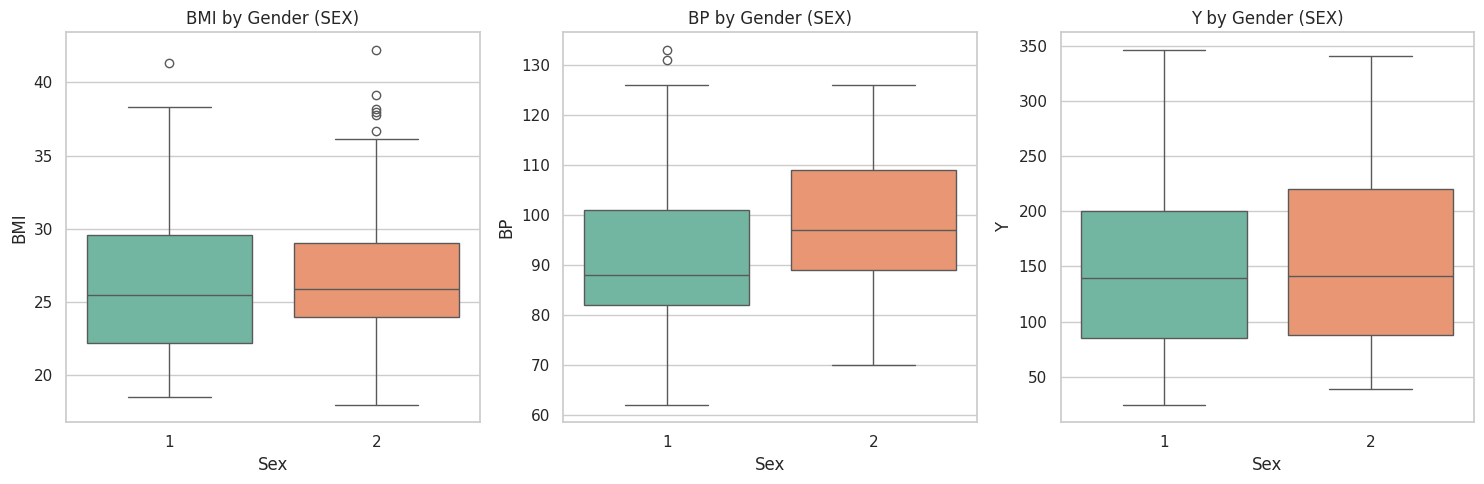

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 从 sample_data 目录读取 diabetes.tsv 文件[cite: 1]
df = pd.read_csv("sample_data/diabetes.tsv", sep='\t')

# 设置图表样式
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 需要绘制的特征列
features = ['BMI', 'BP', 'Y']

# 循环绘制每个变量针对 SEX 的箱线图
for i, col in enumerate(features):
    sns.boxplot(x='SEX', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Gender (SEX)')
    axes[i].set_xlabel('Sex')
    axes[i].set_ylabel(col)

# 调整布局并展示图表
plt.tight_layout()
plt.show()

In [28]:
pd.DataFrame([df.mean(),df.var()],index=['Mean','Variance']).head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
Mean,48.51810,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
Variance,171.84661,0.249561,19.519798,191.304401,1197.717241,924.955494,167.293585,1.665261,0.272892,132.165712,5943.331348


### Task 3: What is the the distribution of Age, Sex, BMI and Y variables?

In [29]:
# Or, more simply, for the mean (variance can be done similarly)
df.mean()

,0
AGE,48.518100
SEX,1.468326
BMI,26.375792
BP,94.647014
S1,189.140271
S2,115.439140
S3,49.788462
S4,4.070249
S5,4.641411
S6,91.260181


### Task 4: Test the correlation between different variables and disease progression (Y)

> **Hint** Correlation matrix would give you the most useful information on which values are dependent.

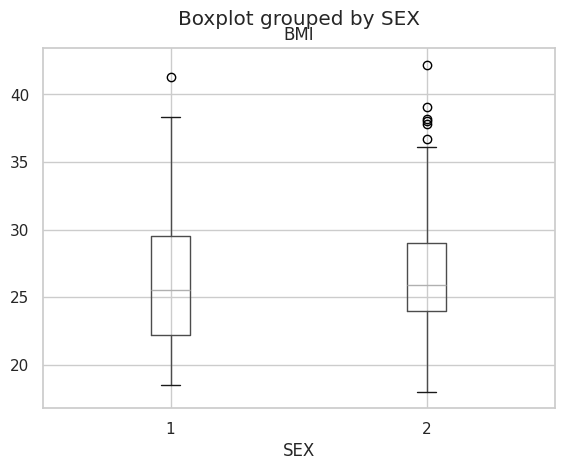

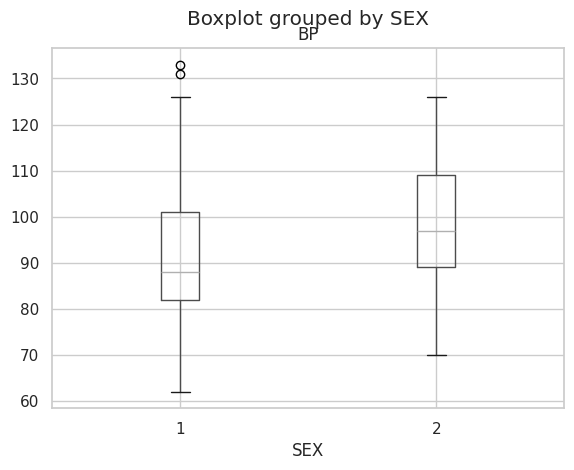

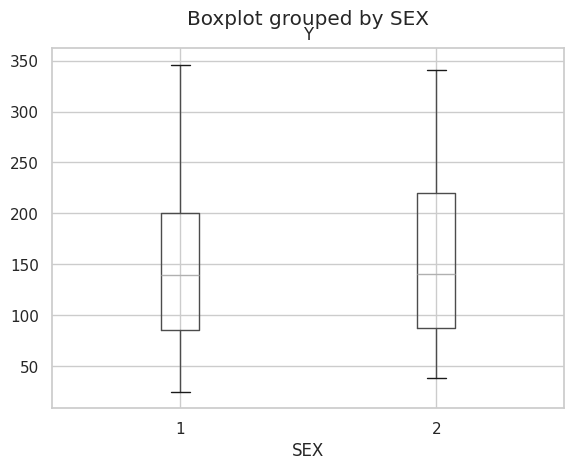

In [30]:
for col in ['BMI','BP','Y']:
    df.boxplot(column=col,by='SEX')
plt.show()

### Task 5: Test the hypothesis that the degree of diabetes progression is different between men and women

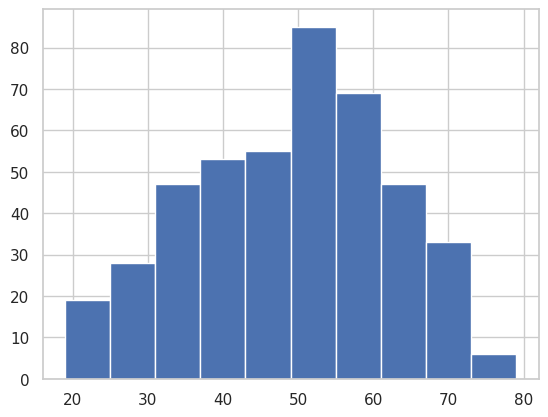

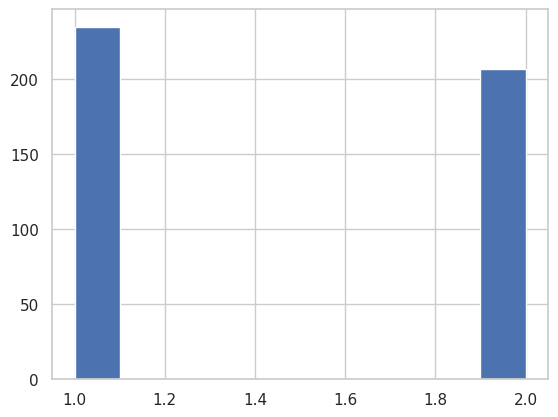

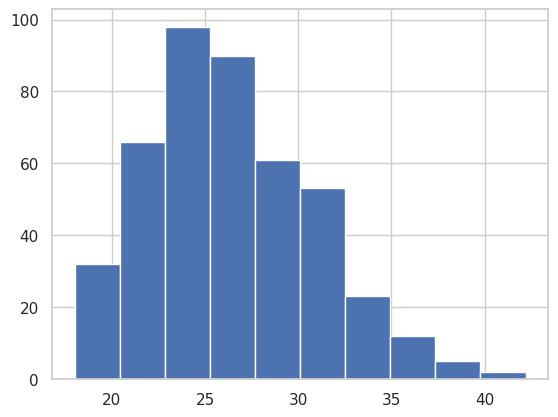

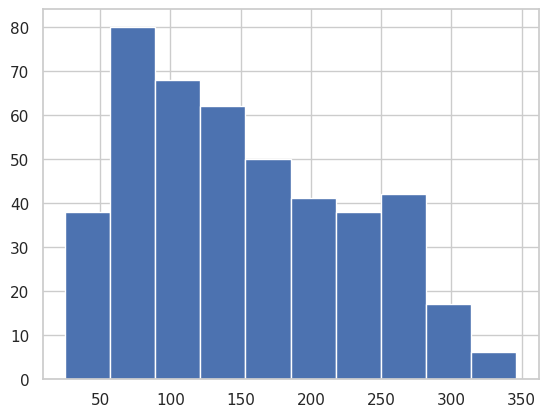

In [31]:
for col in ['AGE','SEX','BMI','Y']:
    df[col].hist()
    plt.show()

In [32]:
df.corr()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
AGE,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
SEX,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
BMI,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
BP,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
S1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
S2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
S3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
S4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
S5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
S6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


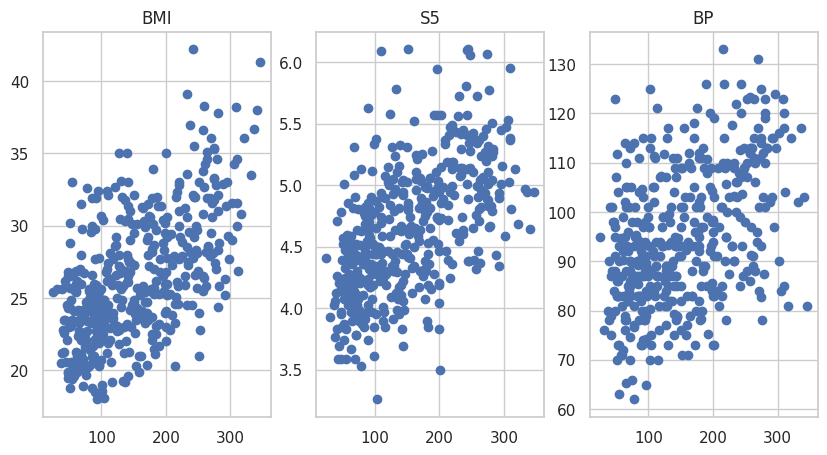

In [33]:
fig, ax = plt.subplots(1,3,figsize=(10,5))
for i,n in enumerate(['BMI','S5','BP']):
    ax[i].scatter(df['Y'],df[n])
    ax[i].set_title(n)
plt.show()

In [34]:
from scipy.stats import ttest_ind

tval, pval = ttest_ind(df.loc[df['SEX']==1,['Y']], df.loc[df['SEX']==2,['Y']],equal_var=False)
print(f"T-value = {tval[0]:.2f}\nP-value: {pval[0]}")

T-value = -0.90
P-value: 0.3674449793083975
